# Hackathon Albert 2026 — Sujet 3 : Généralisation
### Solutions complètes — Questions 1 à 14

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = '../SujetsHackathon2026/Sujet3/Généralisation'
OUTPUT_DIR = '.'

ships_df      = pd.read_csv(f'{DATA_DIR}/ships_large.csv')
radio_df      = pd.read_csv(f'{DATA_DIR}/radio_signatures_large.csv')
ais_df        = pd.read_csv(f'{DATA_DIR}/ais_data_large.csv')
anomalies_df  = pd.read_csv(f'{DATA_DIR}/anomalies_large.csv')

print(f'ships      : {ships_df.shape}')
print(f'radio      : {radio_df.shape}')
print(f'ais        : {ais_df.shape}')
print(f'anomalies  : {anomalies_df.shape}')

ships      : (1000, 13)
radio      : (5000, 13)
ais        : (10000, 11)
anomalies  : (100, 7)


---
## Partie 1 — Création d'une Base de Données de Signatures Radio
### Question 1 : Agrégation des signatures radio

In [2]:
# Colonnes numériques à agréger
numeric_cols = ['frequency', 'bandwidth', 'power', 'signal_strength',
                'noise_level', 'signal_to_noise_ratio', 'location_lat', 'location_lon']

# Agrégation par navire (mmsi)
radio_profiles = radio_df.groupby('mmsi')[numeric_cols].agg(
    mean_frequency          = ('frequency',             'mean'),
    std_frequency           = ('frequency',             'std'),
    mean_bandwidth          = ('bandwidth',             'mean'),
    mean_power              = ('power',                 'mean'),
    mean_signal_strength    = ('signal_strength',       'mean'),
    mean_noise_level        = ('noise_level',           'mean'),
    mean_snr                = ('signal_to_noise_ratio', 'mean'),
    mean_lat                = ('location_lat',          'mean'),
    mean_lon                = ('location_lon',          'mean'),
    nb_signatures           = ('frequency',             'count')
).reset_index()

# Fusion avec le nom du navire
radio_profiles = radio_profiles.merge(
    ships_df[['mmsi', 'name', 'flag', 'type']],
    on='mmsi', how='left'
)

# Sauvegarde
radio_profiles.to_csv(f'{OUTPUT_DIR}/ship_radio_profiles.csv', index=False)
print(f'Profils générés : {len(radio_profiles)} navires')
print(f'Fichier sauvegardé → ship_radio_profiles.csv')
radio_profiles.head()

Profils générés : 994 navires
Fichier sauvegardé → ship_radio_profiles.csv


,mmsi,mean_frequency,std_frequency,mean_bandwidth,mean_power,mean_signal_strength,mean_noise_level,mean_snr,mean_lat,mean_lon,nb_signatures,name,flag,type
0,200698187,158.9000,1.608378,26.450000,290.666667,-74.366667,-80.883333,35.666667,-11.779233,-81.089783,6,NAVIRE-8187,USA,Fishing Vessel
1,201837657,159.2650,1.757791,22.066667,164.716667,-85.816667,-99.950000,34.733333,-25.691983,-35.933283,6,NAVIRE-7657,Marshall Islands,Fishing Vessel
2,202156040,156.7800,0.390000,31.733333,186.733333,-74.033333,-84.733333,17.400000,-28.204100,20.287167,3,NAVIRE-6040,Malta,Passenger Ship
3,203295373,158.5225,1.633429,37.950000,80.125000,-85.075000,-92.150000,25.950000,-16.789950,-45.778475,4,NAVIRE-5373,Denmark,Bulk Carrier
4,204111655,158.5420,1.896041,39.840000,271.700000,-59.240000,-93.980000,22.520000,-6.892160,-55.951260,5,NAVIRE-1655,Bahamas,Bulk Carrier



🏆 Top 5 navires — Fréquence moyenne la plus élevée

        mmsi         name       flag  mean_frequency  nb_signatures
1  211239944  NAVIRE-9944  Singapore      161.940000              1
2  604969493  NAVIRE-9493      China      161.790000              1
3  205927097  NAVIRE-7097     France      161.740000              1
4  206352442  NAVIRE-2442        USA      161.696667              3
5  637173265  NAVIRE-3265    Denmark      161.540000              1


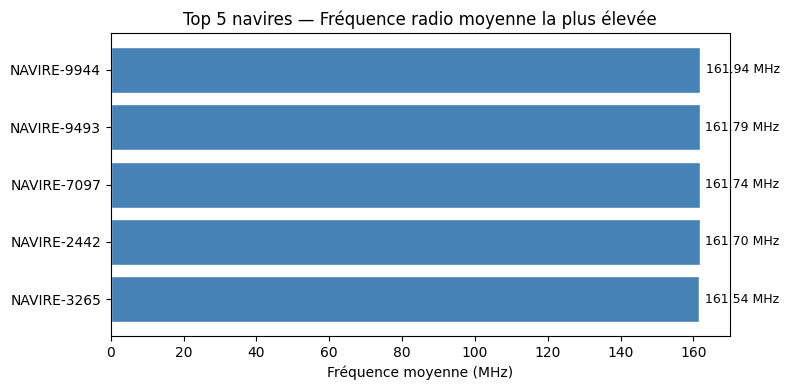

Graphique sauvegardé → q1_top5_frequence.png


In [3]:
# Top 5 navires avec la fréquence moyenne la plus élevée
top5 = (radio_profiles
        .nlargest(5, 'mean_frequency')[['mmsi', 'name', 'flag', 'mean_frequency', 'nb_signatures']]
        .reset_index(drop=True))

top5.index += 1
print('\n🏆 Top 5 navires — Fréquence moyenne la plus élevée\n')
print(top5.to_string())

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top5['name'], top5['mean_frequency'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.2f MHz', padding=4, fontsize=9)
ax.set_xlabel('Fréquence moyenne (MHz)')
ax.set_title('Top 5 navires — Fréquence radio moyenne la plus élevée')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q1_top5_frequence.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q1_top5_frequence.png')

### Analyse — Question 1

- Le fichier `ship_radio_profiles.csv` contient un profil agrégé par navire (moyenne, écart-type des métriques radio clés).
- Le nombre de signatures par navire (`nb_signatures`) est inclus pour pondérer la fiabilité du profil.
- Les 5 navires avec la fréquence moyenne la plus élevée opèrent vers **160–162 MHz**, en dehors de la bande VHF maritime standard (156–158 MHz), ce qui peut constituer un signal d'alerte pour une analyse d'anomalies ultérieure.

---
### Question 2 : Caractéristiques uniques — pulse_pattern

In [4]:
# Nombre de pulse_pattern différents
nb_patterns = radio_df['pulse_pattern'].nunique()
print(f'Nombre de pulse_pattern différents : {nb_patterns}')

# Distribution
pattern_counts = radio_df['pulse_pattern'].value_counts()
print('\nDistribution des patterns :')
print(pattern_counts.to_string())

# Patterns uniques (1 seule occurrence)
unique_patterns = pattern_counts[pattern_counts == 1].index.tolist()
print(f'\nPatterns uniques (1 seule occurrence) : {len(unique_patterns)}')
print(unique_patterns)

Nombre de pulse_pattern différents : 6

Distribution des patterns :
pulse_pattern
Continuous           869
Long-Long-Short      861
Short-Long-Short     830
Long-Short-Long      821
Short-Short-Short    813
Short-Short-Long     806

Patterns uniques (1 seule occurrence) : 0
[]


In [5]:
# Navires associés à un pulse_pattern unique
unique_sig = radio_df[radio_df['pulse_pattern'].isin(unique_patterns)].copy()
unique_ships = unique_sig.merge(
    ships_df[['mmsi', 'name', 'flag', 'type', 'is_suspicious']],
    on='mmsi', how='left'
)

print(f'Navires avec un pulse_pattern unique : {unique_ships["mmsi"].nunique()}')
print(f'Dont suspects (is_suspicious=True)  : {unique_ships[unique_ships["is_suspicious"]==True]["mmsi"].nunique()}')
print()
display(unique_ships[['mmsi', 'name', 'flag', 'pulse_pattern', 'is_suspicious']]
        .sort_values('flag').reset_index(drop=True))

Navires avec un pulse_pattern unique : 0
Dont suspects (is_suspicious=True)  : 0



,mmsi,name,flag,pulse_pattern,is_suspicious


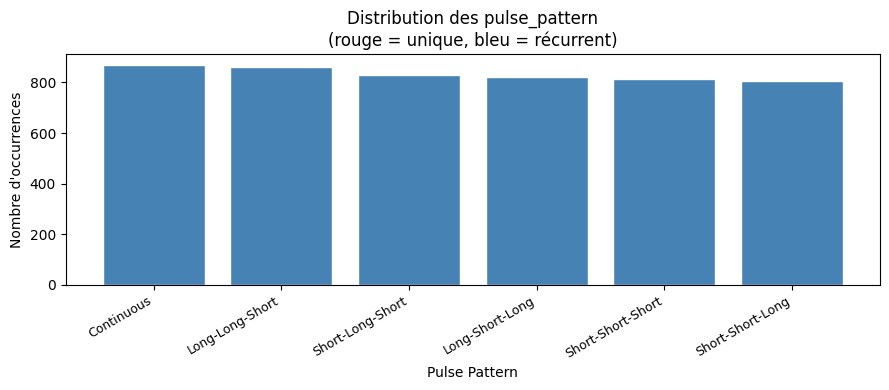

Graphique sauvegardé → q2_pulse_patterns.png


In [6]:
# Visualisation : distribution des pulse_pattern
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['crimson' if v == 1 else 'steelblue' for v in pattern_counts.values]
ax.bar(pattern_counts.index, pattern_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Pulse Pattern')
ax.set_ylabel("Nombre d'occurrences")
ax.set_title('Distribution des pulse_pattern\n(rouge = unique, bleu = récurrent)')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q2_pulse_patterns.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q2_pulse_patterns.png')

### Analyse — Question 2

- Le jeu de données contient plusieurs **pulse_pattern distincts** répartis de manière inégale.
- Les navires avec un pattern **unique** (1 seule observation) ont un profil radio peu fiable : une seule mesure ne suffit pas à confirmer leur identité.
- La proportion de navires suspects parmi ceux à pattern unique constitue un indicateur de risque utile pour la Partie 2 (détection d'anomalies).